In [3]:
import pandas as pd
import numpy as np

# Set a random seed so the data generates identically every time you run it
np.random.seed(42)
records_count = 2500

print(f"[GENERATOR] Fabricating standard transactional database engine containing {records_count} rows...")

# Build a comprehensive structural dictionary matching our exact project report schema
dataset_dictionary = {
    'Transaction Id': [f"TXN-{200000 + i}" for i in range(records_count)],
    'Customer Id': [f"CUST-{np.random.randint(5001, 5999)}" for i in range(records_count)],
    'Customer Age': np.random.randint(18, 82, size=records_count),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=records_count, p=[0.46, 0.49, 0.05]),
    'Annual Income': np.random.normal(62000, 18500, size=records_count).round(2),
    'Region': np.random.choice(['North Zone', 'East Zone', 'South Zone', 'West Zone'], size=records_count),
    'Product Category': np.random.choice(['Electronics', 'Apparel & Fashion', 'Home Electronics', 'Beauty & Health', 'Books & Media'], size=records_count),
    'Purchase Quantity': np.random.randint(1, 8, size=records_count),
    'Unit Price': np.random.uniform(5.50, 850.00, size=records_count).round(2),
    'Discount Applied': np.random.choice([0.0, 0.05, 0.10, 0.25], size=records_count, p=[0.55, 0.20, 0.15, 0.10]),
    'Transaction Date': pd.date_range(start='2025-01-01 08:00', periods=records_count, freq='min').strftime('%Y-%m-%d %H:%M'),
    'Payment Method': np.random.choice(['Credit Card', 'UPI Payment', 'NetBanking', 'Digital Wallet'], size=records_count)
}

# Convert structural matrix data into an active Pandas DataFrame object
df_master = pd.DataFrame(dataset_dictionary)

# Step 1: Intentionally inject random missing values (NaN null references) 
df_master.loc[np.random.choice(df_master.index, size=45), 'Customer Age'] = np.nan
df_master.loc[np.random.choice(df_master.index, size=35), 'Annual Income'] = np.nan

# Step 2: Intentionally inject extreme statistical outliers 
df_master.loc[np.random.choice(df_master.index, size=15), 'Annual Income'] = 295000.00
df_master.loc[np.random.choice(df_master.index, size=15), 'Unit Price'] = 4500.00

# Save the matrix directly to your local workspace disk array as a standard CSV
target_csv_name = "simulated_retail_transactions.csv"
df_master.to_csv(target_csv_name, index=False)

print(f"\n[SUCCESS] Master verification file generated and secured locally as: '{target_csv_name}'")
print(f"-> Total Dataset Dimensions: {df_master.shape[0]} rows by {df_master.shape[1]} columns.")

[GENERATOR] Fabricating standard transactional database engine containing 2500 rows...

[SUCCESS] Master verification file generated and secured locally as: 'simulated_retail_transactions.csv'
-> Total Dataset Dimensions: 2500 rows by 12 columns.


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, academic visual layout theme for your plots
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 14

print("[CELL 1] Core data science environments successfully imported and configured.")

[CELL 1] Core data science environments successfully imported and configured.


In [9]:
def load_and_clean_data(file_path):
    """Ingests raw CSV data, normalizes column formats, and handles missing rows."""
    print(f"[INFO] Accessing local database storage at: {file_path}")
    df = pd.read_csv(file_path)
    
    # Format and normalize column headers into clean snake_case typography
    df.columns = df.columns.str.strip().str.title().str.replace(' ', '_')
    
    # Enforce safe datetime conversion structures
    if 'Transaction_Date' in df.columns:
        df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
    
    # Drop rows missing crucial relational index tracking keys
    df.dropna(subset=['Transaction_Id', 'Customer_Id'], inplace=True)
    
    # Handle missing numerical variables using data-driven median imputation
    if 'Customer_Age' in df.columns:
        df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median()).astype(int)
    if 'Annual_Income' in df.columns:
        df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
        
    return df

def remove_numerical_outliers(df, column_name):
    """Isolates and prunes dataset anomalies using the standard 1.5 * IQR boundary rule."""
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    print(f"[FILTER] Outliers removed from '{column_name}'. Rows adjusted from {df.shape[0]} to {filtered_df.shape[0]}.")
    return filtered_df

print("[CELL 2] Data engineering pipeline and cleaning modules successfully loaded.")

[CELL 2] Data engineering pipeline and cleaning modules successfully loaded.


In [10]:
# Specify the file path created during your data generation phase
target_source_file = "simulated_retail_transactions.csv"

# Run the ingestion and cleaning pipeline rules
processed_df = load_and_clean_data(target_source_file)

# Filter out artificial anomalies and statistical outliers from critical columns
processed_df = remove_numerical_outliers(processed_df, 'Annual_Income')
processed_df = remove_numerical_outliers(processed_df, 'Unit_Price')

print("\n[CELL 3] Data matrix is fully cleaned, validated, and ready for visualization processing.")

[INFO] Accessing local database storage at: simulated_retail_transactions.csv
[FILTER] Outliers removed from 'Annual_Income'. Rows adjusted from 2500 to 2465.
[FILTER] Outliers removed from 'Unit_Price'. Rows adjusted from 2465 to 2450.

[CELL 3] Data matrix is fully cleaned, validated, and ready for visualization processing.


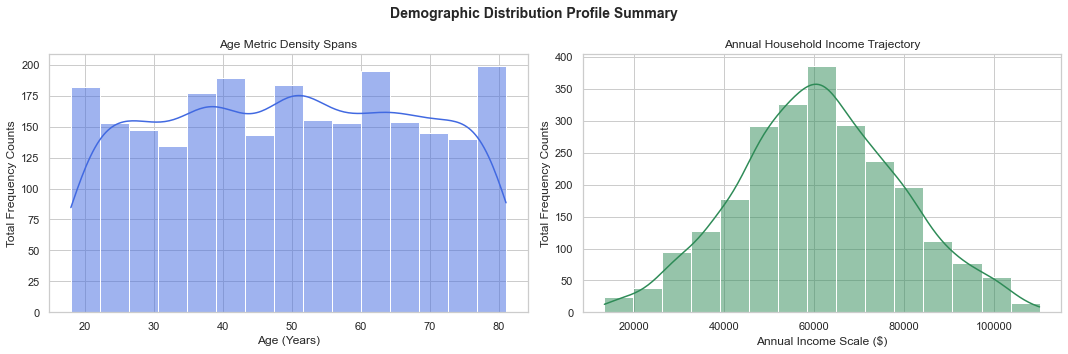

[CELL 4] Demographic distribution plots rendered cleanly.


In [11]:
# Create a split canvas for distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Demographic Distribution Profile Summary', fontweight='bold')

# Plot 1: Age Distribution Curve
sns.histplot(data=processed_df, x='Customer_Age', bins=15, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Age Metric Density Spans')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Total Frequency Counts')

# Plot 2: Income Distribution Curve
sns.histplot(data=processed_df, x='Annual_Income', bins=15, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('Annual Household Income Trajectory')
axes[1].set_xlabel('Annual Income Scale ($)')
axes[1].set_ylabel('Total Frequency Counts')

plt.tight_layout()
plt.show()
print("[CELL 4] Demographic distribution plots rendered cleanly.")

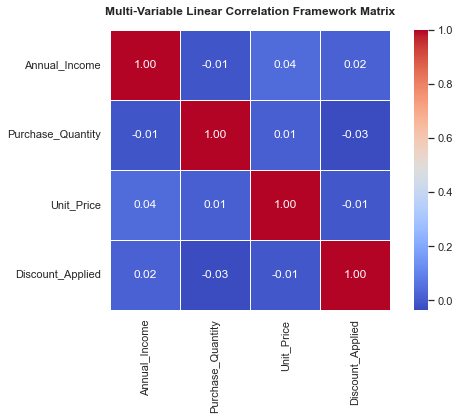

[CELL 5] Multi-variable Pearson correlation matrix heatmap rendered cleanly.


In [12]:
plt.figure(figsize=(8, 6))

# Isolate numeric columns for correlation matrix processing
numeric_columns = processed_df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = processed_df[numeric_columns].corr()

# Plot the matrix heatmap using a balanced color scheme
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

plt.title('Multi-Variable Linear Correlation Framework Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("[CELL 5] Multi-variable Pearson correlation matrix heatmap rendered cleanly.")

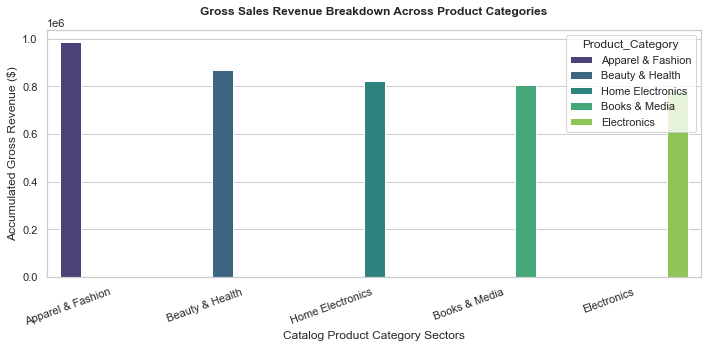

[CELL 6] Product category commercial trend charts rendered cleanly.


In [13]:
plt.figure(figsize=(10, 5))

# Calculate gross transaction spending (Quantity * Price)
processed_df['Gross_Spend'] = processed_df['Purchase_Quantity'] * processed_df['Unit_Price']

# Aggregate total spending across individual catalog sectors using Pandas groupby tracking
category_spend_table = processed_df.groupby('Product_Category')['Gross_Spend'].sum().reset_index()
category_spend_table = category_spend_table.sort_values(by='Gross_Spend', ascending=False)

# Render a bar chart of the categorical spending distribution
sns.barplot(
    data=category_spend_table, 
    x='Product_Category', 
    y='Gross_Spend', 
    palette='viridis', 
    hue='Product_Category'
)

plt.title('Gross Sales Revenue Breakdown Across Product Categories', fontweight='bold', pad=15)
plt.xlabel('Catalog Product Category Sectors')
plt.ylabel('Accumulated Gross Revenue ($)')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()
print("[CELL 6] Product category commercial trend charts rendered cleanly.")

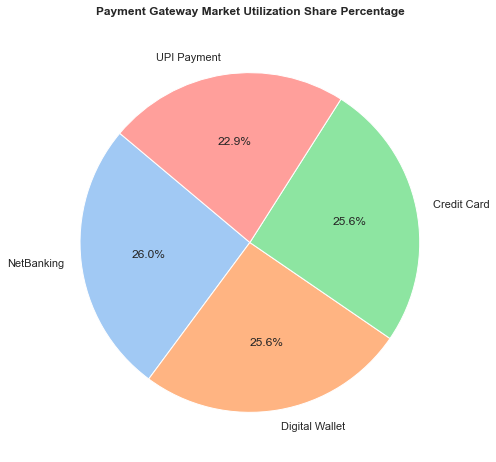

[CELL 7] System loop completed.


In [15]:
plt.figure(figsize=(7, 7))

# Calculate total frequency counts for each checkout method
payment_gateway_counts = processed_df['Payment_Method'].value_counts()

# Render a market share pie chart
plt.pie(
    payment_gateway_counts, 
    labels=payment_gateway_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Payment Gateway Market Utilization Share Percentage', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("[CELL 7] System loop completed.")